In [140]:
import tensorflow as tf
import numpy as np
import os
import json
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential, optimizers
from tensorflow.keras.layers import *

import PIL
from PIL import Image
from matplotlib import cm

In [2]:
data_dir = "/datasets/bailey/2025-07-03"
batch_size=64
# MAT_IMAGE_RESCALE = (64, 27)
MAT_IMAGE_RESCALE = (27, 64)
mat_input_shape = (MAT_IMAGE_RESCALE[0], MAT_IMAGE_RESCALE[1], 1)
# CAMERA_IMAGE_RESCALE = (80, 60)
CAMERA_IMAGE_RESCALE = (60, 80)
camera_input_shape = (CAMERA_IMAGE_RESCALE[0], CAMERA_IMAGE_RESCALE[1], 1)

# Load datasets

In [69]:
train_file_labels = tf.data.experimental.make_csv_dataset(
    os.path.join(data_dir, 'training_frames.csv'), batch_size=batch_size, num_epochs=1)
train_file_labels = train_file_labels.unbatch()
train_file_labels

<_UnbatchDataset element_spec=OrderedDict([('mat_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_image_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_image_path', TensorSpec(shape=(), dtype=tf.string, name=None))])>

In [70]:
validation_file_labels = tf.data.experimental.make_csv_dataset(
    os.path.join(data_dir, 'validation_frames.csv'), batch_size=batch_size, num_epochs=1, 
    shuffle=False)
validation_file_labels = validation_file_labels.unbatch()
validation_file_labels

<_UnbatchDataset element_spec=OrderedDict([('mat_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_image_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_image_path', TensorSpec(shape=(), dtype=tf.string, name=None))])>

In [71]:
test_file_labels = tf.data.experimental.make_csv_dataset(
    os.path.join(data_dir, 'testing_frames.csv'), batch_size=batch_size, num_epochs=1, 
    shuffle=False)
test_file_labels = test_file_labels.unbatch()
test_file_labels

<_UnbatchDataset element_spec=OrderedDict([('mat_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_ts', TensorSpec(shape=(), dtype=tf.string, name=None)), ('mat_image_path', TensorSpec(shape=(), dtype=tf.string, name=None)), ('camera_image_path', TensorSpec(shape=(), dtype=tf.string, name=None))])>

In [72]:
def load_mat_image(file_path):
    # read the image from disk, decode it, resize it, and scale the pixels intensities to the range [0, 1]
    image = tf.io.read_file(file_path)
    image = tf.io.decode_png(image, channels=1)
    # image = tf.image.resize(image, MAT_IMAGE_RESCALE)
    image = tf.cast(image, tf.float32)
    image /= 255.0
    image = tf.ensure_shape(image, mat_input_shape)
    
    is_fall = tf.strings.regex_full_match(file_path, ".*fall.*")
    
    # return the image and the label
    return image, is_fall

In [73]:
def load_camera_image(file_path):
    # read the image from disk, decode it, resize it, and scale the pixels intensities to the range [0, 1]
    image = tf.io.read_file(file_path)
    image = tf.io.decode_png(image, channels=1)
    # image = tf.image.resize(image, MAT_IMAGE_RESCALE)
    # image = tf.ensure_shape(image, mat_input_shape)
    image = tf.cast(image, tf.float32)
    image /= 255.0
    image = tf.ensure_shape(image, camera_input_shape)
    
    is_fall = tf.strings.regex_full_match(file_path, ".*fall.*")
    
    # return the image and the label
    return image, is_fall

In [74]:
def load_mat_camera_image(fl):
    mat_image, is_fall = load_mat_image(fl['mat_image_path'])
    camera_image, _ = load_camera_image(fl['camera_image_path'])
    return {'mat_image': mat_image, 'camera_image': camera_image}, is_fall

In [75]:
mat_train_dataset = train_file_labels.map(
    lambda fl: fl['mat_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_train_dataset = mat_train_dataset.shuffle(1000)
mat_train_dataset = mat_train_dataset.map(
    load_mat_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_train_dataset = mat_train_dataset.batch(batch_size)
mat_train_dataset = mat_train_dataset.prefetch(tf.data.AUTOTUNE)

In [76]:
mat_train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [77]:
mat_validation_dataset = validation_file_labels.map(
    lambda fl: fl['mat_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_validation_dataset = mat_validation_dataset.map(
    load_mat_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_validation_dataset = mat_validation_dataset.batch(batch_size)
mat_validation_dataset = mat_validation_dataset.prefetch(tf.data.AUTOTUNE)

In [78]:
mat_validation_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [79]:
mat_test_dataset = test_file_labels.map(
    lambda fl: fl['mat_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_test_dataset = mat_test_dataset.map(
    load_mat_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_test_dataset = mat_test_dataset.batch(batch_size)
mat_test_dataset = mat_test_dataset.prefetch(tf.data.AUTOTUNE)

In [80]:
mat_test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [81]:
camera_train_dataset = train_file_labels.map(
    lambda fl: fl['camera_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_train_dataset = camera_train_dataset.shuffle(1000)
camera_train_dataset = camera_train_dataset.map(
    load_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_train_dataset = camera_train_dataset.batch(batch_size)
camera_train_dataset = camera_train_dataset.prefetch(tf.data.AUTOTUNE)

In [82]:
camera_train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [83]:
camera_validation_dataset = validation_file_labels.map(
    lambda fl: fl['camera_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_validation_dataset = camera_validation_dataset.map(
    load_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_validation_dataset = camera_validation_dataset.batch(batch_size)
camera_validation_dataset = camera_validation_dataset.prefetch(tf.data.AUTOTUNE)

In [84]:
camera_validation_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [85]:
camera_test_dataset = test_file_labels.map(
    lambda fl: fl['camera_image_path'],
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_test_dataset = camera_test_dataset.map(
    load_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
camera_test_dataset = camera_test_dataset.batch(batch_size)
camera_test_dataset = camera_test_dataset.prefetch(tf.data.AUTOTUNE)

In [86]:
camera_test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [87]:
mat_camera_train_dataset = train_file_labels.map(
    load_mat_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_camera_train_dataset = mat_camera_train_dataset.shuffle(1000)
mat_camera_train_dataset = mat_camera_train_dataset.batch(batch_size)
mat_camera_train_dataset = mat_camera_train_dataset.prefetch(tf.data.AUTOTUNE)

In [88]:
mat_camera_train_dataset

<_PrefetchDataset element_spec=({'mat_image': TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), 'camera_image': TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [89]:
mat_camera_validation_dataset = validation_file_labels.map(
    load_mat_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_camera_validation_dataset = mat_camera_validation_dataset.batch(batch_size)
mat_camera_validation_dataset = mat_camera_validation_dataset.prefetch(tf.data.AUTOTUNE)

In [90]:
mat_camera_validation_dataset

<_PrefetchDataset element_spec=({'mat_image': TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), 'camera_image': TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

In [91]:
mat_camera_test_dataset = test_file_labels.map(
    load_mat_camera_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
mat_camera_test_dataset = mat_camera_test_dataset.batch(batch_size)
mat_camera_test_dataset = mat_camera_test_dataset.prefetch(tf.data.AUTOTUNE)

In [92]:
mat_camera_test_dataset

<_PrefetchDataset element_spec=({'mat_image': TensorSpec(shape=(None, 27, 64, 1), dtype=tf.float32, name=None), 'camera_image': TensorSpec(shape=(None, 60, 80, 1), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.bool, name=None))>

# Mat images only

In [20]:
mat_model_0 = Sequential([
    Input(mat_input_shape),
    Conv2D(filters=4, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=6, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=5, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    #Dropout(rate=0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
mat_model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 62, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 31, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 31, 4)      │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 15, 4)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 15, 4)       │           404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
opt = optimizers.Adam(learning_rate=1e-4)

mat_model_0.compile(
    # optimizer=opt,
    optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [22]:
mat_model_0.input_shape

(None, 27, 64, 1)

In [23]:
history = mat_model_0.fit(
    mat_train_dataset,
    epochs=10,
    validation_data=mat_validation_dataset,
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8788 - loss: 0.3333 - val_accuracy: 0.9964 - val_loss: 0.0108
Epoch 2/10


/usr/lib/python3.11/contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 7.7572e-04
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 6.4262e-04 - val_accuracy: 1.0000 - val_loss: 7.3717e-04
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - loss: 9.1967e-04 - val_accuracy: 1.0000 - val_loss: 4.2479e-04
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 4.1424e-04 - val_accuracy: 1.0000 - val_loss: 4.8665e-04
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.8818e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 - loss: 7.5867e-04 - val_accuracy: 1.0000 - val_loss: 3.8208e-04
Epoch 9/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9995 - lo

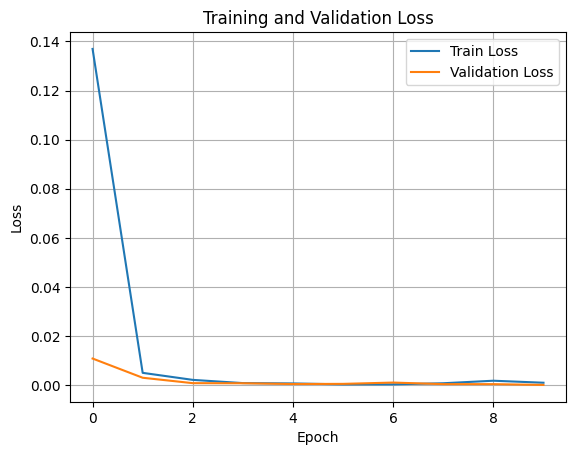

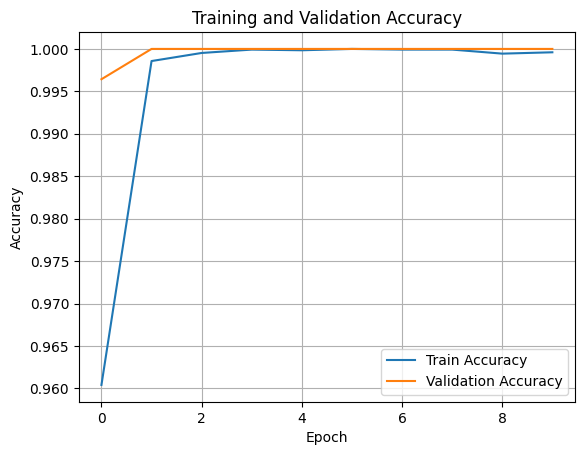

In [24]:
# Assuming history contains the training history returned by model.fit
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [93]:
mat_model_0.evaluate(mat_test_dataset, return_dict=True)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.0000 - loss: 3.7570e-05


{'accuracy': 1.0, 'loss': 4.6682187530677766e-05}

In [104]:
mat_preds = mat_model_0.predict(mat_test_dataset)[:, 0]
mat_preds.shape

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(3361,)

In [105]:
mat_labels = np.array(list(mat_test_dataset.unbatch().map(lambda x, y: y).as_numpy_iterator()))
mat_labels.shape

(3361,)

In [108]:
np.all((mat_preds > 0.5) == mat_labels)

True

# Camera images only

In [27]:
camera_model_0 = Sequential([
    Input(camera_input_shape),
    Conv2D(filters=4, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=6, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    Conv2D(filters=4, kernel_size=5, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2),
    #Dropout(rate=0.5),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
camera_model_0.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 58, 78, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 29, 39, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 39, 4)      │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 19, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 19, 4)      │           404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 9, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 252)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,537 (131.00 KB)

 Trainable params: 33,537 (131.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
opt = optimizers.Adam(learning_rate=1e-4)

camera_model_0.compile(
    # optimizer=opt,
    optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [29]:
camera_model_0.input_shape

(None, 60, 80, 1)

In [30]:
history = camera_model_0.fit(
    camera_train_dataset,
    epochs=10,
    validation_data=camera_validation_dataset,
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8173 - loss: 0.3593 - val_accuracy: 0.9762 - val_loss: 0.0672
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9864 - loss: 0.0420 - val_accuracy: 0.9869 - val_loss: 0.0224
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9945 - loss: 0.0194 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9963 - loss: 0.0114 - val_accuracy: 0.9988 - val_loss: 0.0039
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9986 - loss: 0.0064 - val_accuracy: 0.9952 - val_loss: 0.0086
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9991 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 6.3420e-04
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9999 - loss: 7.2661e-04 - val_accu

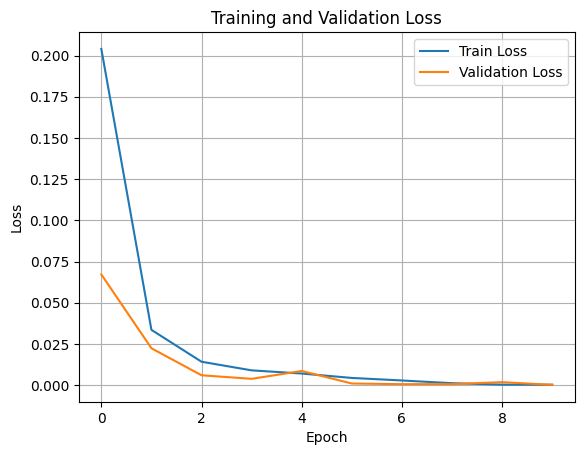

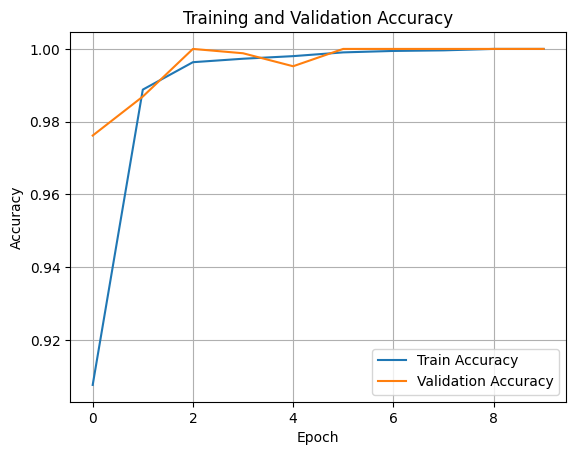

In [31]:
# Assuming history contains the training history returned by model.fit
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
camera_model_0.evaluate(camera_test_dataset, return_dict=True)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - loss: 0.0012


{'accuracy': 0.9997024536132812, 'loss': 0.0014412986347451806}

In [109]:
cam_preds = camera_model_0.predict(camera_test_dataset)[:, 0]
cam_preds.shape

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


(3361,)

In [110]:
cam_labels = np.array(list(camera_test_dataset.unbatch().map(lambda x, y: y).as_numpy_iterator()))
cam_labels.shape

(3361,)

In [117]:
np.unique((cam_preds > 0.5) == cam_labels, return_counts = True)

(array([False,  True]), array([   1, 3360]))

In [137]:
wrongs = list(tf.data.Dataset.zip(camera_test_dataset.unbatch(), tf.data.Dataset.from_tensor_slices(cam_preds > 0.5)).filter(lambda il, p : p != il[1]).map(lambda il2, _: il2[0]).as_numpy_iterator())
len(wrongs)

1

In [149]:
wds = tf.data.Dataset.zip(camera_test_dataset.unbatch(), tf.data.Dataset.from_tensor_slices(cam_preds > 0.5), tf.data.Dataset.counter())
wds = wds.filter(lambda il, p, n: p != il[1])
wds.as_numpy_iterator().next()

((array([[[0.6862745 ],
          [0.85882354],
          [0.8039216 ],
          ...,
          [0.75686276],
          [0.8156863 ],
          [0.67058825]],
  
         [[0.7176471 ],
          [0.77254903],
          [0.83137256],
          ...,
          [0.7490196 ],
          [0.7921569 ],
          [0.6784314 ]],
  
         [[0.78431374],
          [0.8352941 ],
          [0.8039216 ],
          ...,
          [0.7019608 ],
          [0.8666667 ],
          [0.7764706 ]],
  
         ...,
  
         [[0.627451  ],
          [0.6392157 ],
          [0.6156863 ],
          ...,
          [0.6862745 ],
          [0.6901961 ],
          [0.6431373 ]],
  
         [[0.6392157 ],
          [0.65882355],
          [0.627451  ],
          ...,
          [0.7254902 ],
          [0.70980394],
          [0.5921569 ]],
  
         [[0.5647059 ],
          [0.6901961 ],
          [0.60784316],
          ...,
          [0.6901961 ],
          [0.7529412 ],
          [0.6117647 ]]], dtype=f

In [154]:
tf.data.Dataset.zip(test_file_labels, tf.data.Dataset.counter()).skip(711).as_numpy_iterator().next()

(OrderedDict([('mat_path',
               b'/datasets/bailey/2025-07-03/data/pm_adl/sd/50ealspb.csv'),
              ('mat_ts', b'2024-07-09T12:41:12.050000+01:00'),
              ('camera_path',
               b'/datasets/bailey/2025-07-03/data/ir_adl/sd/50ealspb'),
              ('camera_ts', b'2024-07-09T12:41:12.062674'),
              ('mat_image_path',
               b'/datasets/bailey/2025-07-03/images/adl_image/sd/50ealspb/2024-07-09T12:41:12.062674.mat.png'),
              ('camera_image_path',
               b'/datasets/bailey/2025-07-03/images/adl_image/sd/50ealspb/2024-07-09T12:41:12.062674.camera.png')]),
 711)

In [146]:
wrongs[0][:, :, 0].shape

(60, 80)

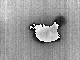

In [147]:
im = Image.fromarray((wrongs[0][:, :, 0] * 255).astype(np.uint8), mode='L')
im

# Mat and camera images

In [49]:
mc_mat_0_input = Input(mat_input_shape, name="mat_image")
x = Conv2D(filters=4, kernel_size=3, activation='relu')(mc_mat_0_input)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(filters=4, kernel_size=6, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(filters=4, kernel_size=5, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)
# x = Dropout(rate=0.5)(x)
x = Flatten()(x)
mc_mat_0_dense = Dense(128)(x)

In [48]:
mc_camera_0_input = Input(camera_input_shape, name="camera_image")
x = Conv2D(filters=4, kernel_size=3, activation='relu')(mc_camera_0_input)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(filters=4, kernel_size=6, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(filters=4, kernel_size=5, padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=2)(x)
# x = Dropout(rate=0.5)(x)
x = Flatten()(x)
mc_camera_0_dense = Dense(128)(x)

In [53]:
x = concatenate([mc_mat_0_dense, mc_camera_0_dense])
x = Dense(32)(x)
mc_0_output = Dense(1, activation='sigmoid')(x)

mc_0_model = tf.keras.Model(
    inputs=[mc_mat_0_input, mc_camera_0_input],
    outputs=[mc_0_output],
)

In [56]:
# tf.keras.utils.plot_model(mc_0_model, "multi_input_and_output_model.png", show_shapes=True)

In [57]:
opt = optimizers.Adam(learning_rate=1e-4)

mc_0_model.compile(
    # optimizer=opt,
    optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [58]:
history = mc_0_model.fit(
    mat_camera_train_dataset,
    epochs=10,
    validation_data=mat_camera_validation_dataset,
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8914 - loss: 0.2267 - val_accuracy: 1.0000 - val_loss: 9.2168e-04
Epoch 2/10


/usr/lib/python3.11/contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 6.4403e-04 - val_accuracy: 1.0000 - val_loss: 3.3697e-04
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.3583e-04 - val_accuracy: 1.0000 - val_loss: 2.7469e-04
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 5.7530e-05 - val_accuracy: 1.0000 - val_loss: 1.2918e-04
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 3.7878e-05 - val_accuracy: 1.0000 - val_loss: 9.2045e-05
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 2.4154e-05 - val_accuracy: 1.0000 - val_loss: 9.4100e-05
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 2.1160e-05 - val_accuracy: 1.0000 - val_loss: 7.3753e-05
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.3292e-05 - val_accuracy: 1.0000 - val_loss: 1.3423e-04
Epoch 9/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accur

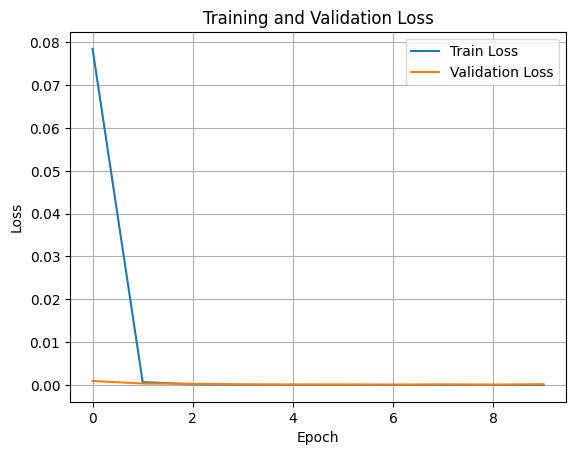

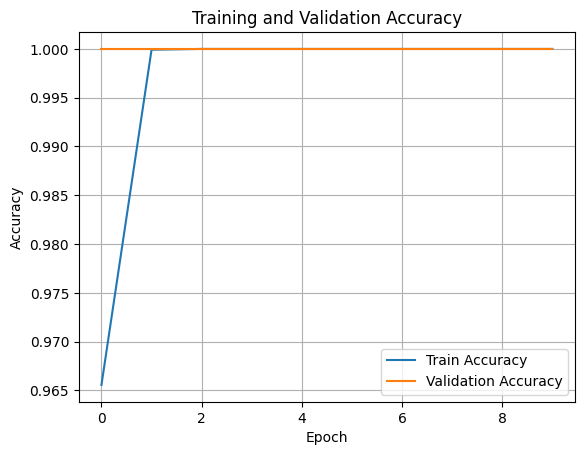

In [59]:
# Assuming history contains the training history returned by model.fit
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
mc_0_model.evaluate(mat_camera_test_dataset, return_dict=True)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 4.7918e-06


{'accuracy': 1.0, 'loss': 4.852086931350641e-06}